In [22]:
# !pip3 install -U transformers tokenizers huggingface_hub bitsandbytes accelerate

In [23]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login

In [ ]:
hf_token = 'hf_xxx'

In [41]:
# Standard HF setup — login() authenticates your session with the huggingface Hub
login(hf_token)

In [5]:
tokenizer = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-v0.1', trust_remote_code=True)

In [6]:
text = "Tell me recent advancements into AI"
tokens = tokenizer.encode(text)
tokens

[1, 15259, 528, 5391, 8670, 1339, 778, 16107]

In [7]:
len(tokenizer.vocab)

32000

In [26]:
qwen_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-32B', trust_remote_code=True)
text = "Tell me recent advancements into AI"
tokens = qwen_tokenizer.encode(text)
tokens

[40451, 752, 3213, 82687, 1119, 15235]

In [27]:
from transformers import BitsAndBytesConfig
import torch
import gc

In [28]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

In [42]:
# !pip3 install -U bitsandbytes

In [34]:
model = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-v0.1', device_map="auto", torch_dtype=torch.float16)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:25<00:00, 12.76s/it]
Some parameters are on the meta device because they were offloaded to the disk.


In [35]:
memory = model.get_memory_footprint() / 1e6
print(f"Memory footprint: {memory:,.1f} MB")

Memory footprint: 14,483.5 MB


In [36]:
model

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): MistralRMSNorm((4096,)

In [39]:
inputs = tokenizer(text, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=80)
outputs[0]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


tensor([    1, 15259,   528,  5391,  8670,  1339,   778, 16107,   304,  5599,
         5168, 28723,    13,    13,  1014,  1080,  5391,  8670,  1339,   297,
        16107,   304,  5599,  5168,   460,   297,   272,  1834,   302,  3534,
         5168, 28723, 14972,  5168,   349,   264,  1212,   302,  5599,  5168,
          369,  6098, 18278, 25726, 12167,   298,  2822,   477,  1178, 28723,
        14972,  5168,   659,   750,  1307,   298, 12049,   264,  6677,   302,
         4418, 28725,  2490,  3469, 13828, 28725,  4229,  3842,  9457, 28725,
          304,  8666, 13828, 28723,    13,    13,  3195,   460,   272,  7196,
          302, 16107,   304,  5599,  5168, 28804,    13,    13],
       device='mps:0')

In [40]:
tokenizer.decode(outputs[0])

'<s> Tell me recent advancements into AI and machine learning.\n\nThe most recent advancements in AI and machine learning are in the field of deep learning. Deep learning is a type of machine learning that uses artificial neural networks to learn from data. Deep learning has been used to solve a variety of problems, including image recognition, natural language processing, and speech recognition.\n\nWhat are the benefits of AI and machine learning?\n\n'

### Tokenizer and Model are downloaded into cache and saved and loaded from cache.

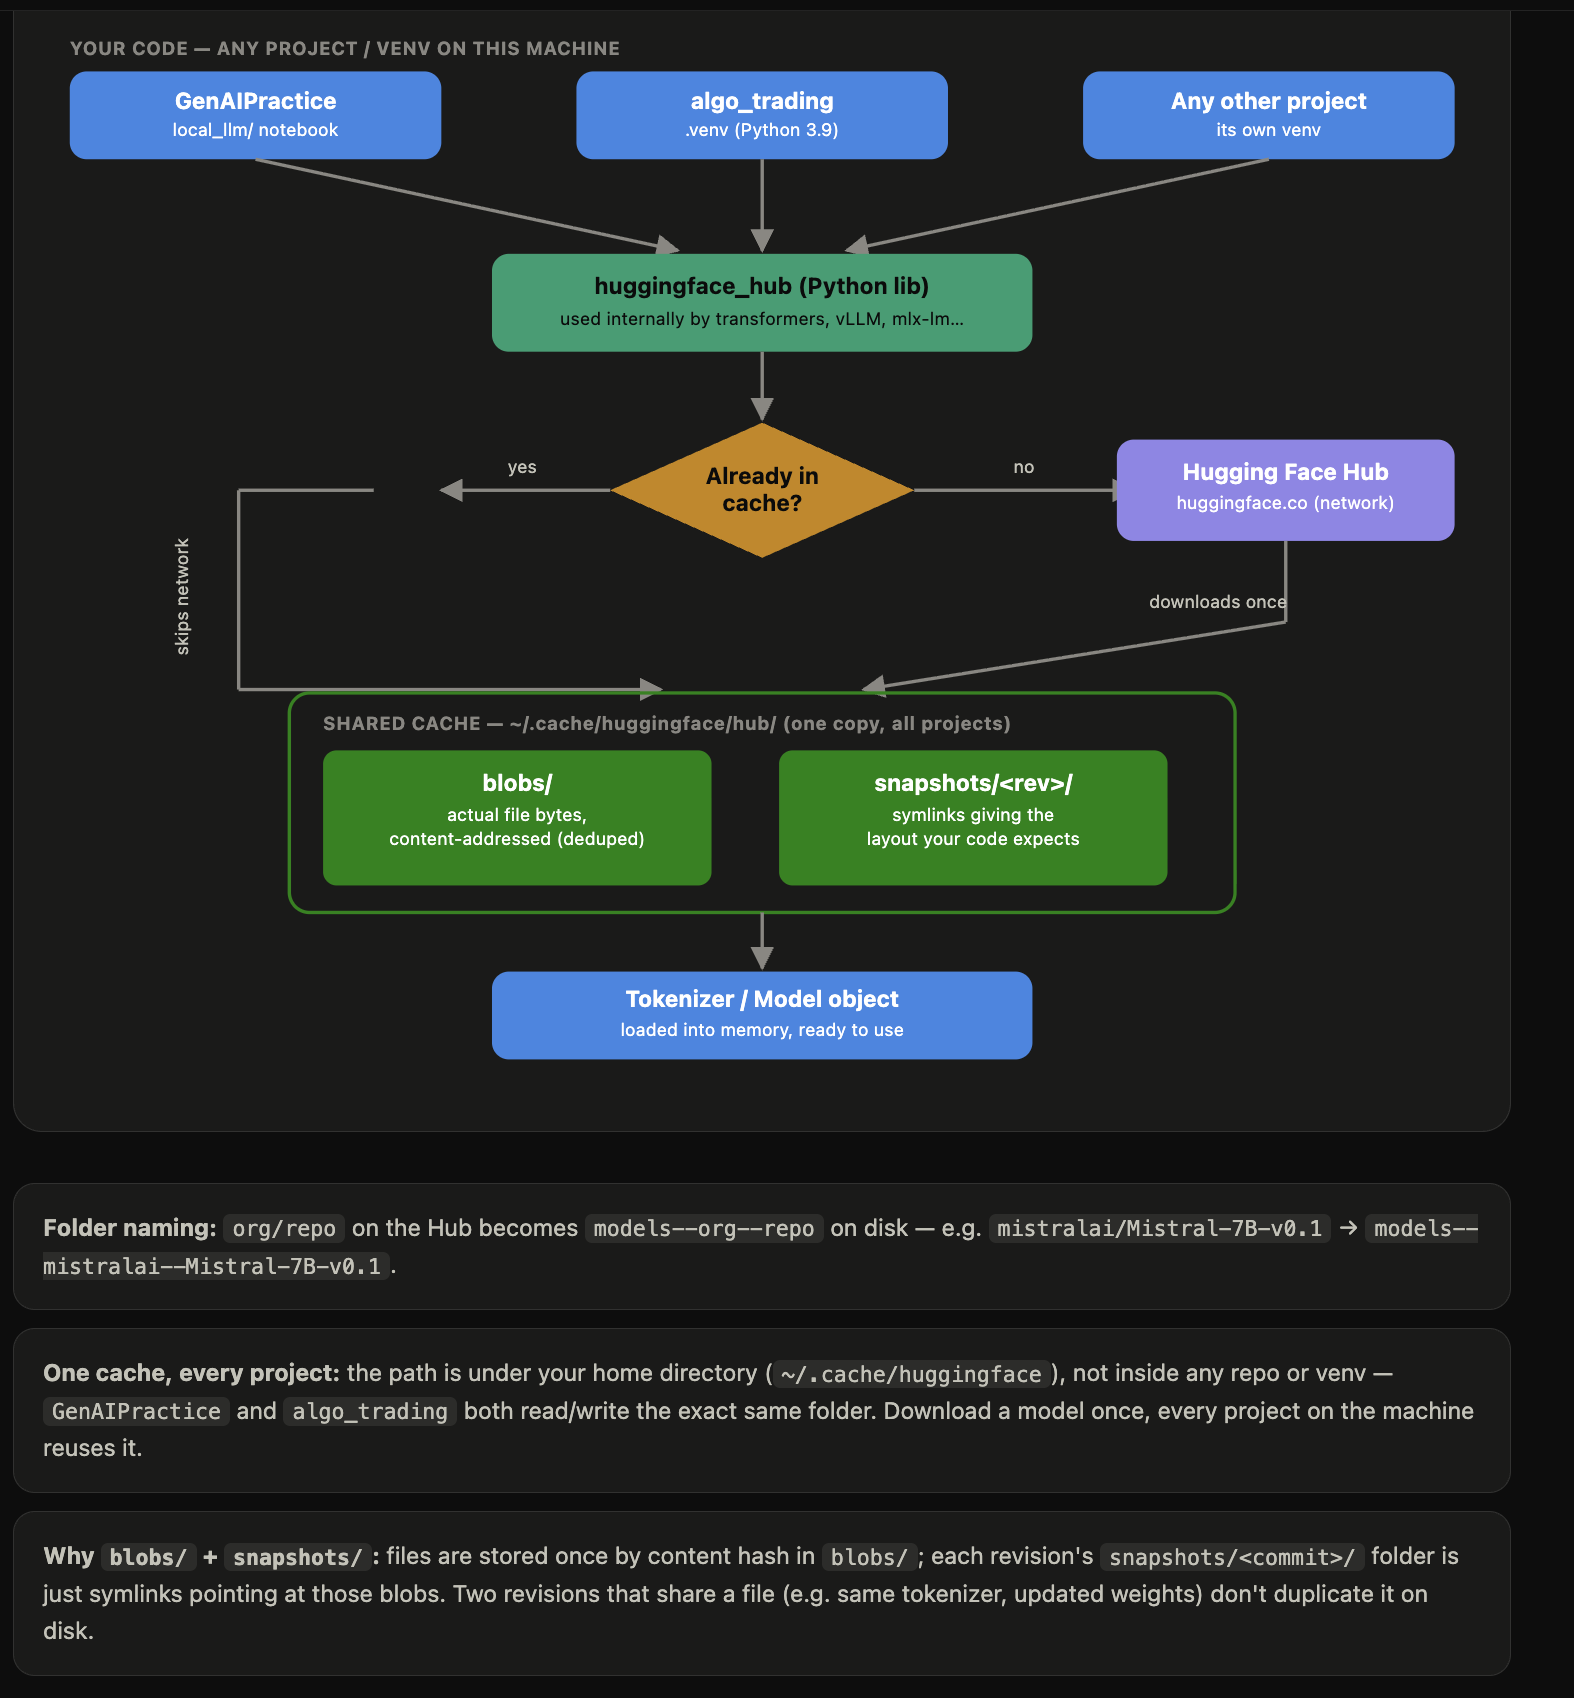

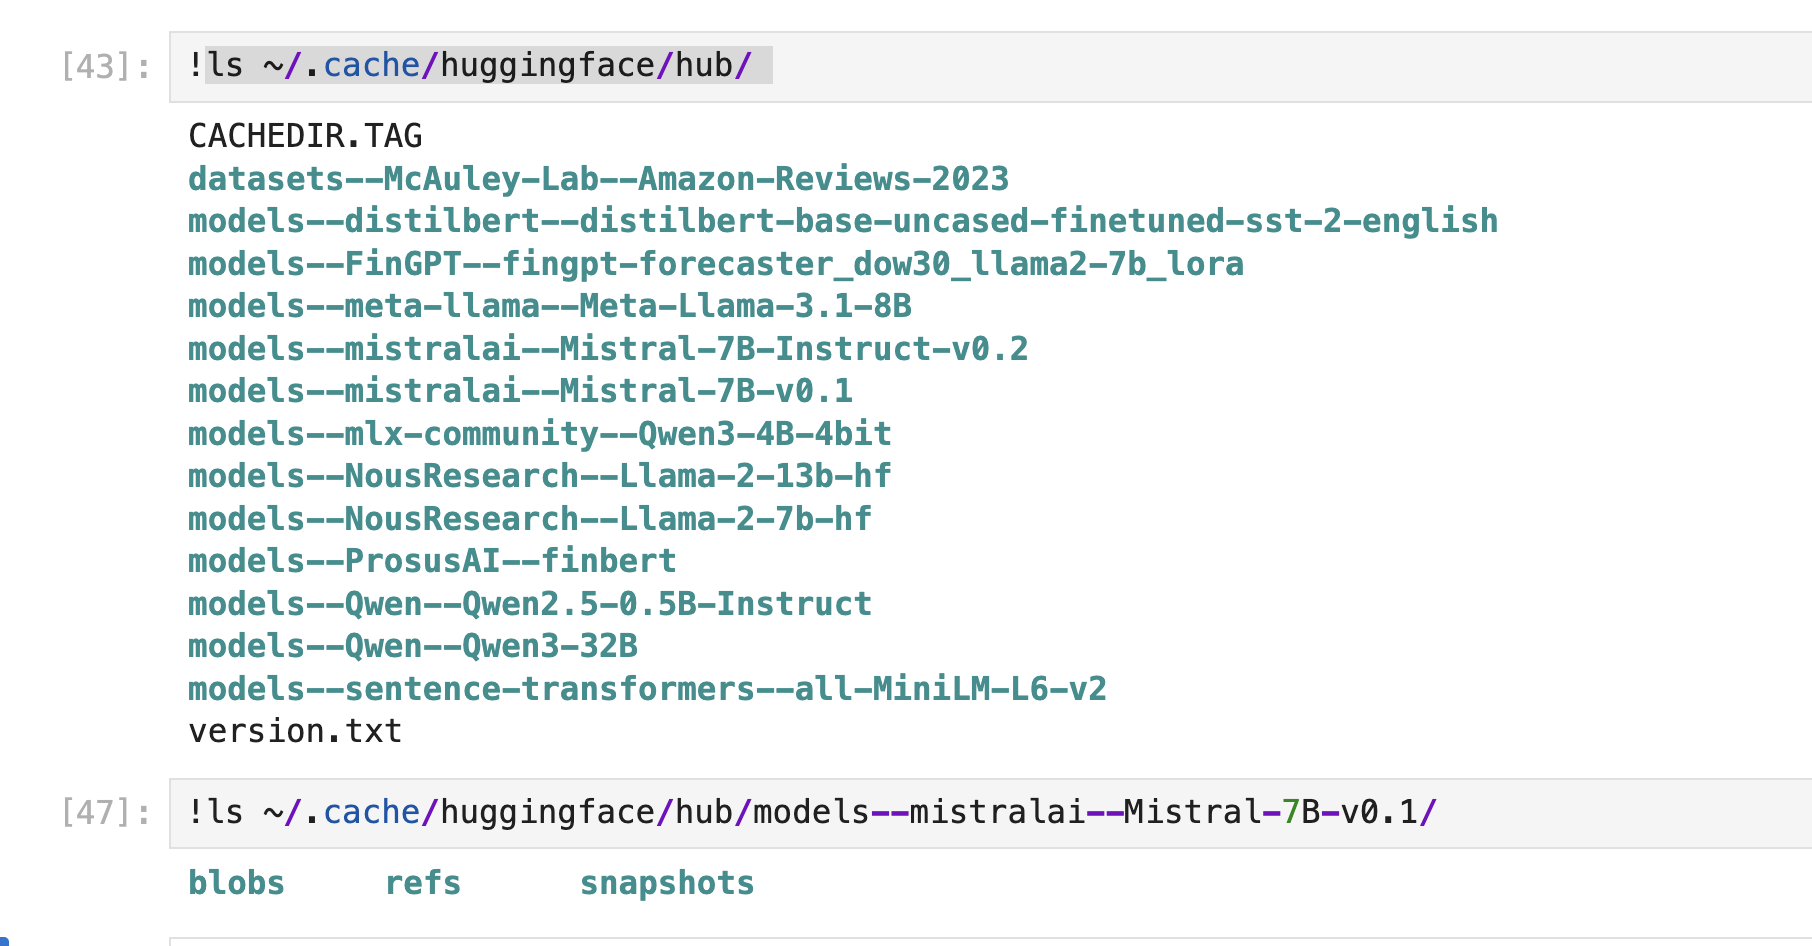

In [43]:
!ls ~/.cache/huggingface/hub/ 

CACHEDIR.TAG
datasets--McAuley-Lab--Amazon-Reviews-2023
models--distilbert--distilbert-base-uncased-finetuned-sst-2-english
models--FinGPT--fingpt-forecaster_dow30_llama2-7b_lora
models--meta-llama--Meta-Llama-3.1-8B
models--mistralai--Mistral-7B-Instruct-v0.2
models--mistralai--Mistral-7B-v0.1
models--mlx-community--Qwen3-4B-4bit
models--NousResearch--Llama-2-13b-hf
models--NousResearch--Llama-2-7b-hf
models--ProsusAI--finbert
models--Qwen--Qwen2.5-0.5B-Instruct
models--Qwen--Qwen3-32B
models--sentence-transformers--all-MiniLM-L6-v2
version.txt


In [47]:
!ls ~/.cache/huggingface/hub/models--mistralai--Mistral-7B-v0.1/

blobs     refs      snapshots


## Various files inside a model in huggingface

### Model Config
* **config.json** — the model's blueprint: hidden size (4096), number of layers (32), number of attention heads, vocab size (32000), etc. This is what AutoModelForCausalLM reads first to build the empty model skeleton (the MistralForCausalLM structure you saw printed earlier) before loading any actual weights into it.
* **generation_config.json** — default generation settings (max length, which token IDs count as end-of-sequence, etc.) that model.generate() falls back to unless you override them 

### Model Weights
* **model-00001-of-00002.safetensors** and **model-00002-of-00002.safetensors** the real trained parameters (billions of floating-point numbers), split into 2 shards because 7B params doesn't fit comfortably in one file (HF shards large models, roughly ~5GB per piece). .safetensors is the modern weight format — a plain tensor container with no executable code, replacing the older pickle-based .bin format that could run arbitrary code on load (a real supply-chain risk safetensors was built to close).
* **model.safetensors.index.json** — a manifest mapping every parameter name (e.g. model.layers.14.self_attn.q_proj.weight) to which of the two shard files actually holds it, so loading code knows where to look without opening both files blindly.

### Tokenizers
* **tokenizer.json** — the fast (Rust-backed) tokenizer's complete serialized state: vocabulary, merge rules, normalization rules.
  * model.vocab — 32,000 entries mapping string piece → integer id
  * model.merges — 58,980 ordered merge rules, e.g. ▁ t, i n, e r... These are literally the BPE (Byte-Pair Encoding) training history: start from individual characters, and repeatedly merge whichever adjacent pair was most frequent in the training corpus, in the order discovered. At encode time, the tokenizer replays these merges greedily on your input.
  * model.type: "BPE" — confirms the algorithm.
* **tokenizer.model** — the original raw SentencePiece binary the tokenizer was originally trained with (Mistral/Llama-style tokenizers are built on SentencePiece); tokenizer.json is essentially a derived, faster-loading version of this.
* **tokenizer_config.json** — metadata about how to construct the tokenizer object (which class, max sequence length, special token names, chat template if the model has one).
  * "add_bos_token": true,
  * "add_eos_token": false,
  * "tokenizer_class": "LlamaTokenizer",
  * "model_max_length": 1e+21
* **special_tokens_map.json** — which literal strings map to which special roles (<s> → bos, </s> → eos, <unk> → unk, etc.) — this is why token 1 in your earlier output was the beginning-of-sequence marker.
  * "bos_token": "<s>",   // beginning of sequence
  * "eos_token": "</s>",  // end of sequence
  * "unk_token": "<unk>"  // unknown/out-of-vocab fallback